# 06 · Kernels, classification, and windows with gaps

The method's claim is about **laws**, not about any one term library, any one
task or any one sampling grid. This notebook takes each of those away:

1. **A kernel basis instead of the library** -- and the zoo's one failure,
   `sin 4x` against `sin 4.6x`, comes back.
2. **Classification instead of clustering** -- a class is a *set* of laws,
   and the plug-in learning curve is a formula (V10).
3. **Real data where windows have different designs** -- UCR series sampled
   irregularly, and I-94 traffic days with sensor gaps, scored at the hours
   that were observed.

Every live cell runs in seconds; the full results are read from `results/`.

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from lrdsr import viz
viz.style()
pd.set_option("display.precision", 4)
RES = ROOT / "results"

## 1 · A kernel basis repairs the gap outside the span

`high_frequency` from the problem zoo: two laws the fast library cannot tell
apart well, because 37% of their *difference* is outside its span. A Nystrom
basis of an RBF kernel spans a function space instead; its rank is the one
knob.

In [2]:
from experiments.problems.zoo import PROBLEMS, make_windows, sigma_for_rho, oracle_labels
from experiments.kernel.run import gap_outside_basis, _snr
from lrdsr.core.kernel import NystromBasis
from lrdsr.core.mechanism_space import mechanism_features, mechanism_init, mechanism_noise
from lrdsr.core.evaluation import aligned_accuracy
from sklearn.cluster import KMeans

prob = next(p for p in PROBLEMS if p.name == "high_frequency")
X, y, z = make_windows(prob, sigma_for_rho(prob, 0.25), 150, 48, seed=11)
def err(lab):
    return 1 - aligned_accuracy(z, lab)


print(f"oracle            {err(oracle_labels(prob, X, y)):.3f}")
print(f"library           {err(mechanism_init(X, y, 2, seed=11, feature_names=['x'])):.3f}")
for r in (4, 8, 12, 16, 24):
    b = NystromBasis(r).fit(X.reshape(-1, 1))
    S = mechanism_features(X, y, basis=b)
    lab = KMeans(2, n_init=30, random_state=11).fit_predict(S)
    print(f"Nystrom rank {b.rank:2d}  {err(lab):.3f}   gap outside {gap_outside_basis(prob, b):6.1%}"
          f"   SNR {_snr(S, mechanism_noise(X, y, basis=b)):.2f}")

oracle            0.040
library           0.100


Nystrom rank  5  0.400   gap outside  96.7%   SNR 0.03
Nystrom rank  9  0.113   gap outside  46.9%   SNR 0.57
Nystrom rank 13  0.047   gap outside   0.4%   SNR 1.22
Nystrom rank 17  0.047   gap outside   0.0%   SNR 1.10
Nystrom rank 25  0.053   gap outside   0.0%   SNR 0.79


The rank is chosen **without labels**: the rank that maximises the spectral
SNR of mechanism space (excess spread over the noise, per root dimension).
That rule was picked over per-window leave-one-out on the *tuning* seeds; the
sweep over every problem is in `results/kernel/`.

,mech_kernel,mech_library,oracle,profile_kmeans,soft_em_kernel,soft_em_library
problem,,,,,,
damping,0.005,0.009,0.0,0.283,0.020,0.022
four_way,0.030,0.036,0.0,0.091,0.015,0.013
frequency_shift,0.002,0.003,0.0,0.084,0.001,0.004
high_frequency,0.055,0.079,0.0,0.336,0.051,0.096
interaction,0.007,0.004,0.0,NaN,0.006,0.005
kink,0.007,0.007,0.0,0.087,0.008,0.006
moment_matched,0.007,0.010,0.0,0.048,-0.001,0.009
moving_step,0.033,0.016,0.0,0.173,0.059,0.025
power_exponent,0.009,0.004,0.0,0.044,0.007,0.007


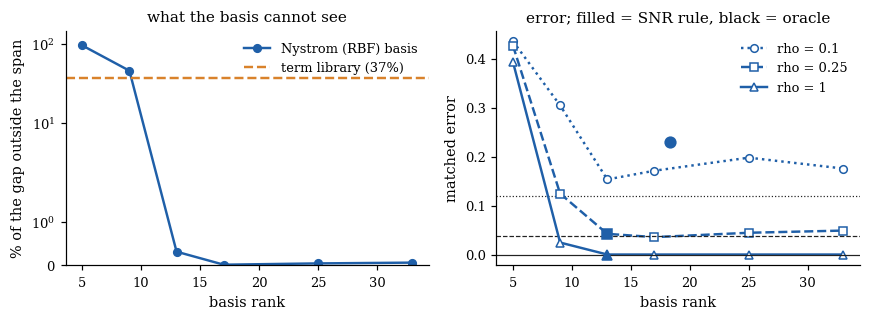

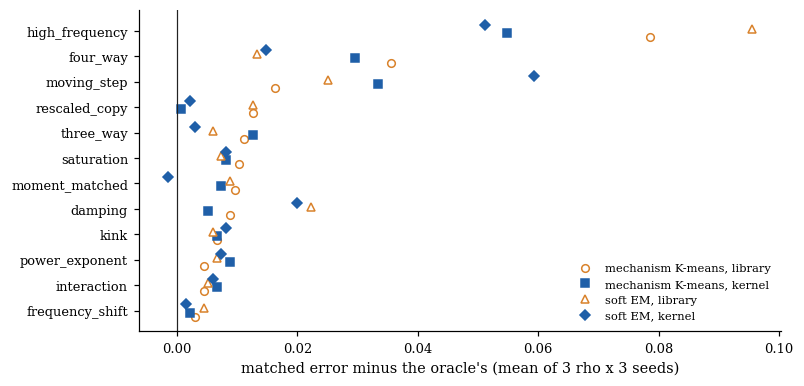

In [3]:
from analysis.figs_kernel import kernel_rank_sweep, kernel_zoo
kernel_rank_sweep(); kernel_zoo()
pd.read_csv(RES / "kernel" / "kernel_zoo_summary.csv").set_index("problem").round(3)

## 2 · Classification: the learning curve is a formula (V10)

With labels, fit the laws per class and send a window to the class whose law
explains it. With a basis of rank $p$ and $m$ labelled windows per class,
the plug-in error is

$$P_{err} \approx Q\left(\frac{D^2}{2\sqrt{D^2 + 2p/m}}\right),\qquad D^2 = n\rho,$$

and exactly a three-scalar expectation. **The price is $p/m$**: the basis
dimension, not the window length.

p= 3 m= 1  simulated 0.210  exact 0.175  first order 0.123  ceiling 0.067


p=15 m= 2  simulated 0.190  exact 0.210  first order 0.179  ceiling 0.067


p=31 m= 8  simulated 0.146  exact 0.144  first order 0.136  ceiling 0.067


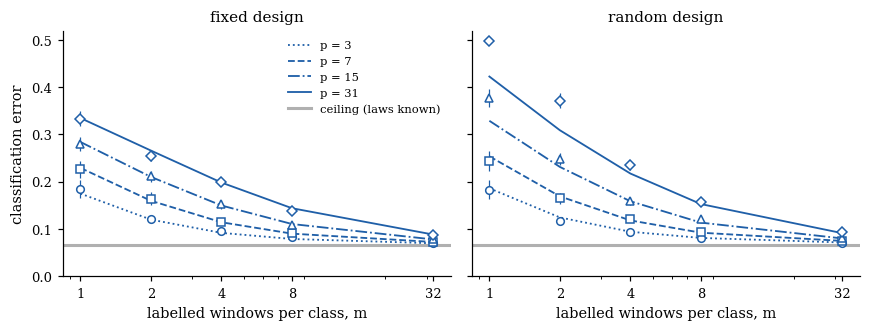

In [4]:
from lrdsr.theory.classification import plugin_error, plugin_error_first_order, _simulate, Q
for p, m in ((3, 1), (15, 2), (31, 8)):
    sims = [_simulate("fixed", 9.0, p, m, s, n_test=500)[0] for s in range(30)]
    print(f"p={p:2d} m={m:2d}  simulated {np.mean(sims):.3f}  exact {plugin_error(9.0, p, m):.3f}"
          f"  first order {plugin_error_first_order(9.0, p, m):.3f}  ceiling {Q(1.5):.3f}")
from analysis.figs_classify import v10_learning_curve
v10_learning_curve();

## 3 · A class is a set of laws

`LawClassifier` fits `L` laws per class with the hard LR-DSR loop inside
each class. `L = 1` is the linear rule; `L = "all"` makes every training
series its own law (nearest law). Chinatown: pedestrian counts, weekday or
weekend, 20 training days.

L = 1    laws   2  test error 0.210
L = 2    laws   4  test error 0.050
L = 4    laws   8  test error 0.079
L = all  laws  20  test error 0.050


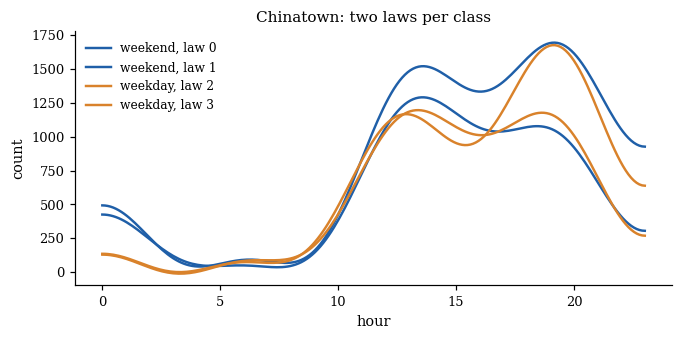

In [5]:
from experiments.classify import ucr
from lrdsr.core.classify import LawClassifier
from lrdsr.core.kernel import CosineBasis

ds = ucr.load("Chinatown")
Xtr, ytr = ucr.to_windows(ds.train); Xte, yte = ucr.to_windows(ds.test)
for L in (1, 2, 4, "all"):
    clf = LawClassifier(basis=CosineBasis(8), nuisance=None, laws_per_class=L).fit(Xtr, ytr, ds.y_train)
    print(f"L = {L!s:4} laws {clf.n_laws:3d}  test error {np.mean(clf.predict(Xte, yte) != ds.y_test):.3f}")

clf = LawClassifier(basis=CosineBasis(8), nuisance=None, laws_per_class=2).fit(Xtr, ytr, ds.y_train)
grid = np.linspace(0, 1, 200)[:, None]
fig, ax = plt.subplots(figsize=(7, 3))
for j, c in enumerate(clf.law_class_):
    ax.plot(grid[:, 0] * 23, clf.design_.B(grid) @ clf.coef_[j], color=viz.regime_color(c),
            label=f"{('weekend', 'weekday')[c]}, law {j}")
ax.set(xlabel="hour", ylabel="count", title="Chinatown: two laws per class"); ax.legend(fontsize=8);

**Irregular sampling.** Keep a random quarter of each series' hours -- a
different quarter per series. The law classifier scores the kept samples at
their own times; a profile method has to interpolate first.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
for keep in (1.0, 0.5, 0.25):
    tr = ucr.subsample(ds.train, keep, 11) if keep < 1 else ds.train
    te = ucr.subsample(ds.test, keep, 12) if keep < 1 else ds.test
    Xa, ya = ucr.to_windows(tr); Xb, yb = ucr.to_windows(te)
    law = LawClassifier(basis=CosineBasis(8), nuisance=None, laws_per_class=2).fit(Xa, ya, ds.y_train)
    nn = KNeighborsClassifier(1).fit(ucr.to_grid(tr, 24), ds.y_train)
    print(f"keep {keep:4.0%}  law {np.mean(law.predict(Xb, yb) != ds.y_test):.3f}   "
          f"interpolated 1-NN {np.mean(nn.predict(ucr.to_grid(te, 24)) != ds.y_test):.3f}")

keep 100%  law 0.050   interpolated 1-NN 0.055


keep  50%  law 0.198   interpolated 1-NN 0.140
keep  25%  law 0.251   interpolated 1-NN 0.362


### The 24-dataset benchmark

Nine daily-cycle datasets (the kind of data this method is for) and fifteen
shape benchmarks (the contrast). Hyperparameters by CV on the training split,
test split touched once.

In [7]:
b = pd.read_csv(RES / "classify" / "ucr_benchmark.csv")
b.pivot_table(index=["group", "dataset"], columns="method", values="error").round(3)

method                        law_cosine  law_nystrom  law_symbolic  \
group dataset                                                         
daily Chinatown                    0.076        0.064         0.219   
      DodgerLoopDay                0.412        0.388         0.525   
      DodgerLoopGame               0.094        0.087         0.254   
      DodgerLoopWeekend            0.029        0.022         0.029   
      ElectricDevices              0.433        0.429         0.517   
      ItalyPowerDemand             0.046        0.052         0.097   
      MelbournePedestrian          0.077        0.073         0.296   
      PowerCons                    0.022        0.017         0.100   
      SmallKitchenAppliances       0.347        0.336         0.515   
shape ArrowHead                    0.189        0.194         0.606   
      CBF                          0.106        0.049         0.281   
      Coffee                       0.000        0.000         0.143   
      ECG200                       0.150        0.120         0.260   
      FaceFour                     0.159        0.193         0.818   
      GunPoint                     0.087        0.087         0.327   
      Lightning2                   0.246        0.295         0.344   
      Lightning7                   0.356        0.301         0.438   
      MoteStrain                   0.157        0.157         0.208   
      Plane                        0.029        0.048         0.267   
      SonyAIBORobotSurface1        0.288        0.301         0.474   
      SyntheticControl             0.003        0.003         0.113   
      Trace                        0.260        0.270         0.450   
      TwoPatterns                  0.058        0.057         0.392   
      Wafer                        0.009        0.010         0.332   

method                        mech_logistic  mech_svm  published_1nn_dtw  \
group dataset                                                              
daily Chinatown                       0.023     0.038              0.047   
      DodgerLoopDay                   0.412     0.400              0.412   
      DodgerLoopGame                  0.116     0.080              0.072   
      DodgerLoopWeekend               0.029     0.029              0.022   
      ElectricDevices                 0.517     0.404              0.381   
      ItalyPowerDemand                0.048     0.055              0.045   
      MelbournePedestrian             0.092     0.066              0.184   
      PowerCons                       0.000     0.000              0.078   
      SmallKitchenAppliances          0.317     0.304              0.328   
shape ArrowHead                       0.229     0.229              0.200   
      CBF                             0.148     0.030              0.004   
      Coffee                          0.036     0.036              0.000   
      ECG200                          0.250     0.140              0.120   
      FaceFour                        0.068     0.125              0.114   
      GunPoint                        0.107     0.080              0.087   
      Lightning2                      0.197     0.213              0.131   
      Lightning7                      0.329     0.370              0.288   
      MoteStrain                      0.137     0.130              0.134   
      Plane                           0.019     0.029              0.000   
      SonyAIBORobotSurface1           0.373     0.271              0.304   
      SyntheticControl                0.037     0.010              0.017   
      Trace                           0.160     0.160              0.010   
      TwoPatterns                     0.120     0.060              0.002   
      Wafer                           0.101     0.006              0.004   

method                        published_1nn_ed  raw_1nn_ed  raw_centroid  \
group dataset                                                              
daily Chinatown         

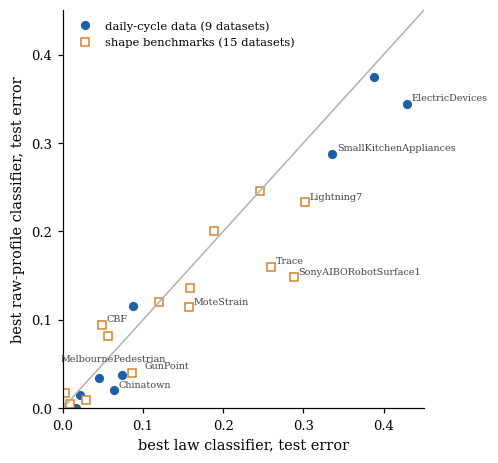

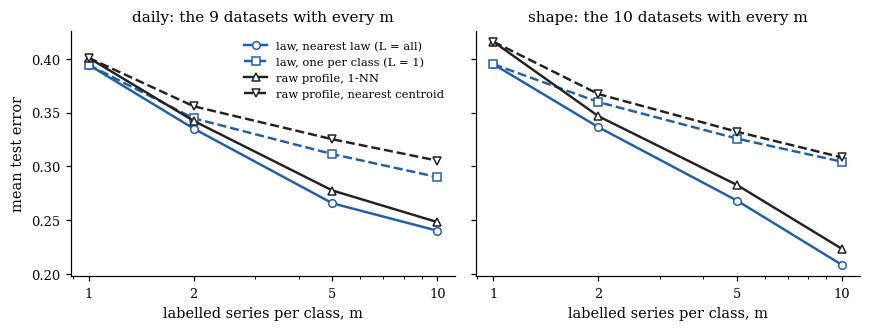

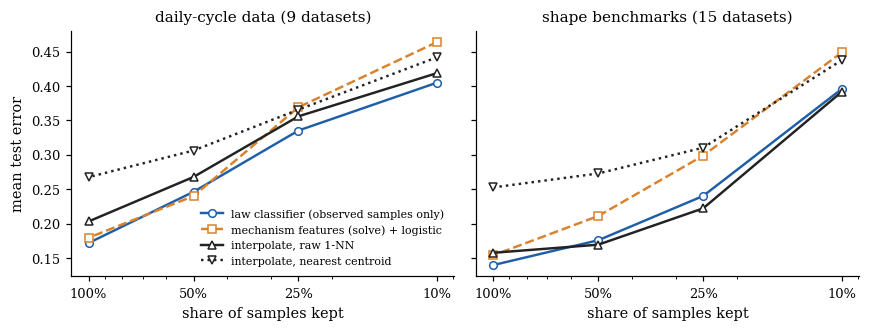

In [8]:
from analysis.figs_classify import classify_benchmark, classify_fewshot, classify_irregular
classify_benchmark(); classify_fewshot(); classify_irregular();

## 4 · I-94 days with sensor gaps

The first pass at the real data dropped every traffic day with a missing hour
-- a third of the days. Score each partial day at the hours it has, with its
level as a nuisance, and compare with imputing the gaps first.

1214 complete days, 616 partial days with >= 6 hours


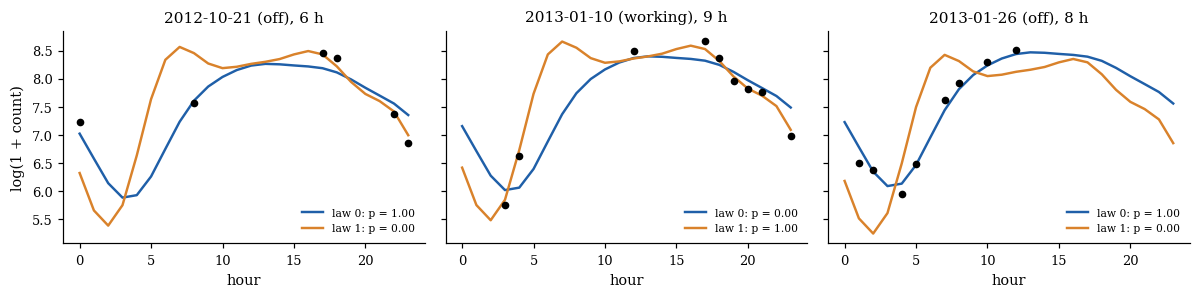

In [9]:
from experiments.realdata import gaps
days = gaps.traffic_days()
part = days[~days.complete]
print(f"{days.complete.sum()} complete days, {len(part)} partial days with >= {gaps.MIN_HOURS} hours")
c, lab = gaps._cluster_complete(days, seed=11)
Xc, yc = gaps.windows(c["hours"], c["count"])
law = LawClassifier(basis=gaps._fourier(), nuisance="intercept").fit(Xc, yc, lab)

few = part[part.n_hours <= 9].head(3)
fig, axes = plt.subplots(1, len(few), figsize=(11, 2.8), sharey=True)
hh = np.arange(24); xg = (2 * np.pi * hh / 24)[:, None]
for ax, (_, d) in zip(axes, few.iterrows()):
    Xd, yd = gaps.windows([d.hours], [d["count"]])
    p = law.predict_proba(Xd, yd)[0]
    for k in range(2):
        f = law.design_.B(xg) @ law.coef_[k]
        off = np.mean(yd[0] - (law.design_.B(Xd[0]) @ law.coef_[k]))
        ax.plot(hh, f + off, color=viz.regime_color(k), label=f"law {k}: p = {p[k]:.2f}")
    ax.plot(d.hours, yd[0], "ko", ms=4)
    ax.set(title=f"{d.date:%Y-%m-%d} ({'working' if d.reference else 'off'}), {d.n_hours} h",
           xlabel="hour")
    ax.legend(fontsize=7)
axes[0].set_ylabel("log(1 + count)"); fig.tight_layout()

route                   law  profile_linear  profile_mean
arm        hours_bin                                     
assign     (11, 17]   0.966           0.921         0.980
           (17, 22]   0.981           0.981         0.977
           (22, 23]   0.975           0.975         0.975
           (5, 11]    1.000           0.711         0.868
           all        0.976           0.943         0.971
supervised (11, 17]   0.966           0.921         0.980
           (17, 22]   0.981           0.981         0.977
           (22, 23]   0.975           0.969         0.975
           (5, 11]    1.000           0.684         0.921
           all        0.976           0.940         0.974

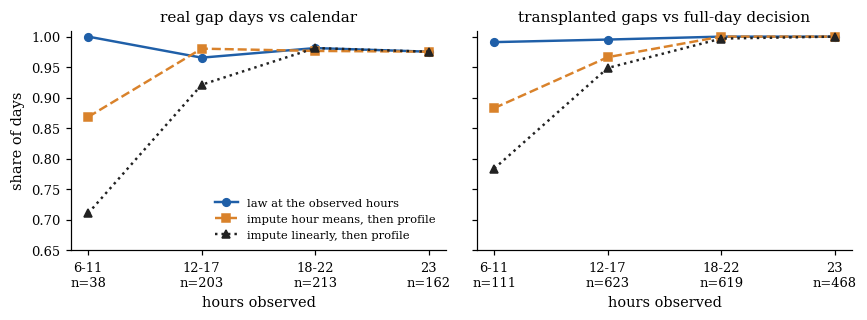

In [10]:
from analysis.figs_realdata import realdata_gaps
realdata_gaps()
pd.read_csv(RES / "realdata" / "realdata_gaps_summary.csv").pivot_table(
    index=["arm", "hours_bin"], columns="route", values="accuracy").round(3)